In [ ]:
#Importar Librerias

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import glob

# GetImage

notebook_dir = os.getcwd()
project_dir = os.path.dirname(notebook_dir)
image_folder = os.path.join(project_dir, 'results', '02_Registro_de_Imagenes')
image_paths = glob.glob(os.path.join(image_folder, '*.jpg'))
image_paths.sort()
images = [cv2.imread(path) for path in image_paths]

print(f"Loaded {len(images)} images:")
for path in image_paths:
    print(" -", os.path.basename(path))

img1 = cv2.imread(image_paths[0])
img2 = cv2.imread(image_paths[1])

Loaded 2 images:
 - resultAkaze.jpg
 - resultOrb.jpg


# Mostrar la imagen y segmentar

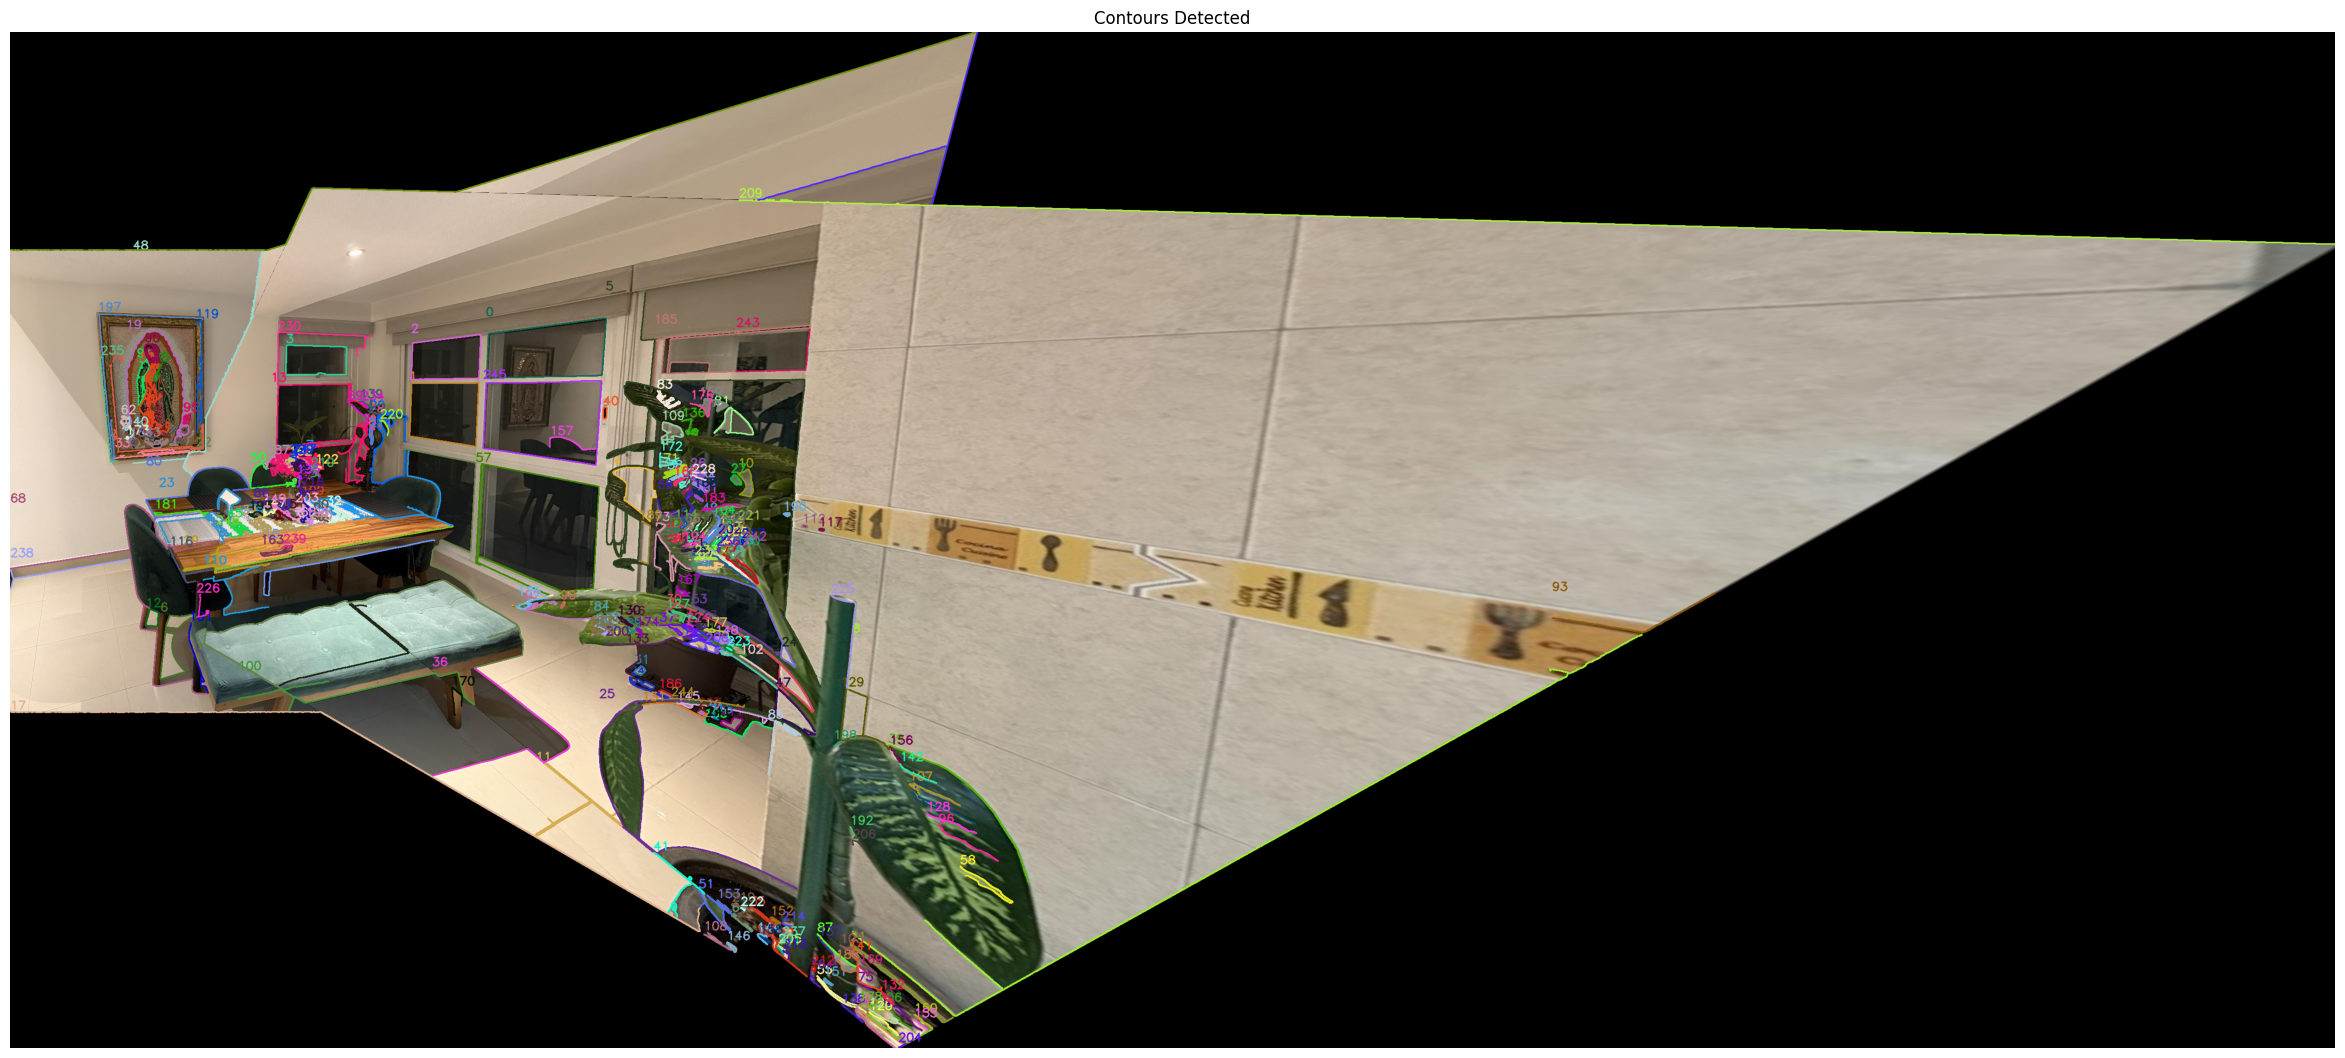

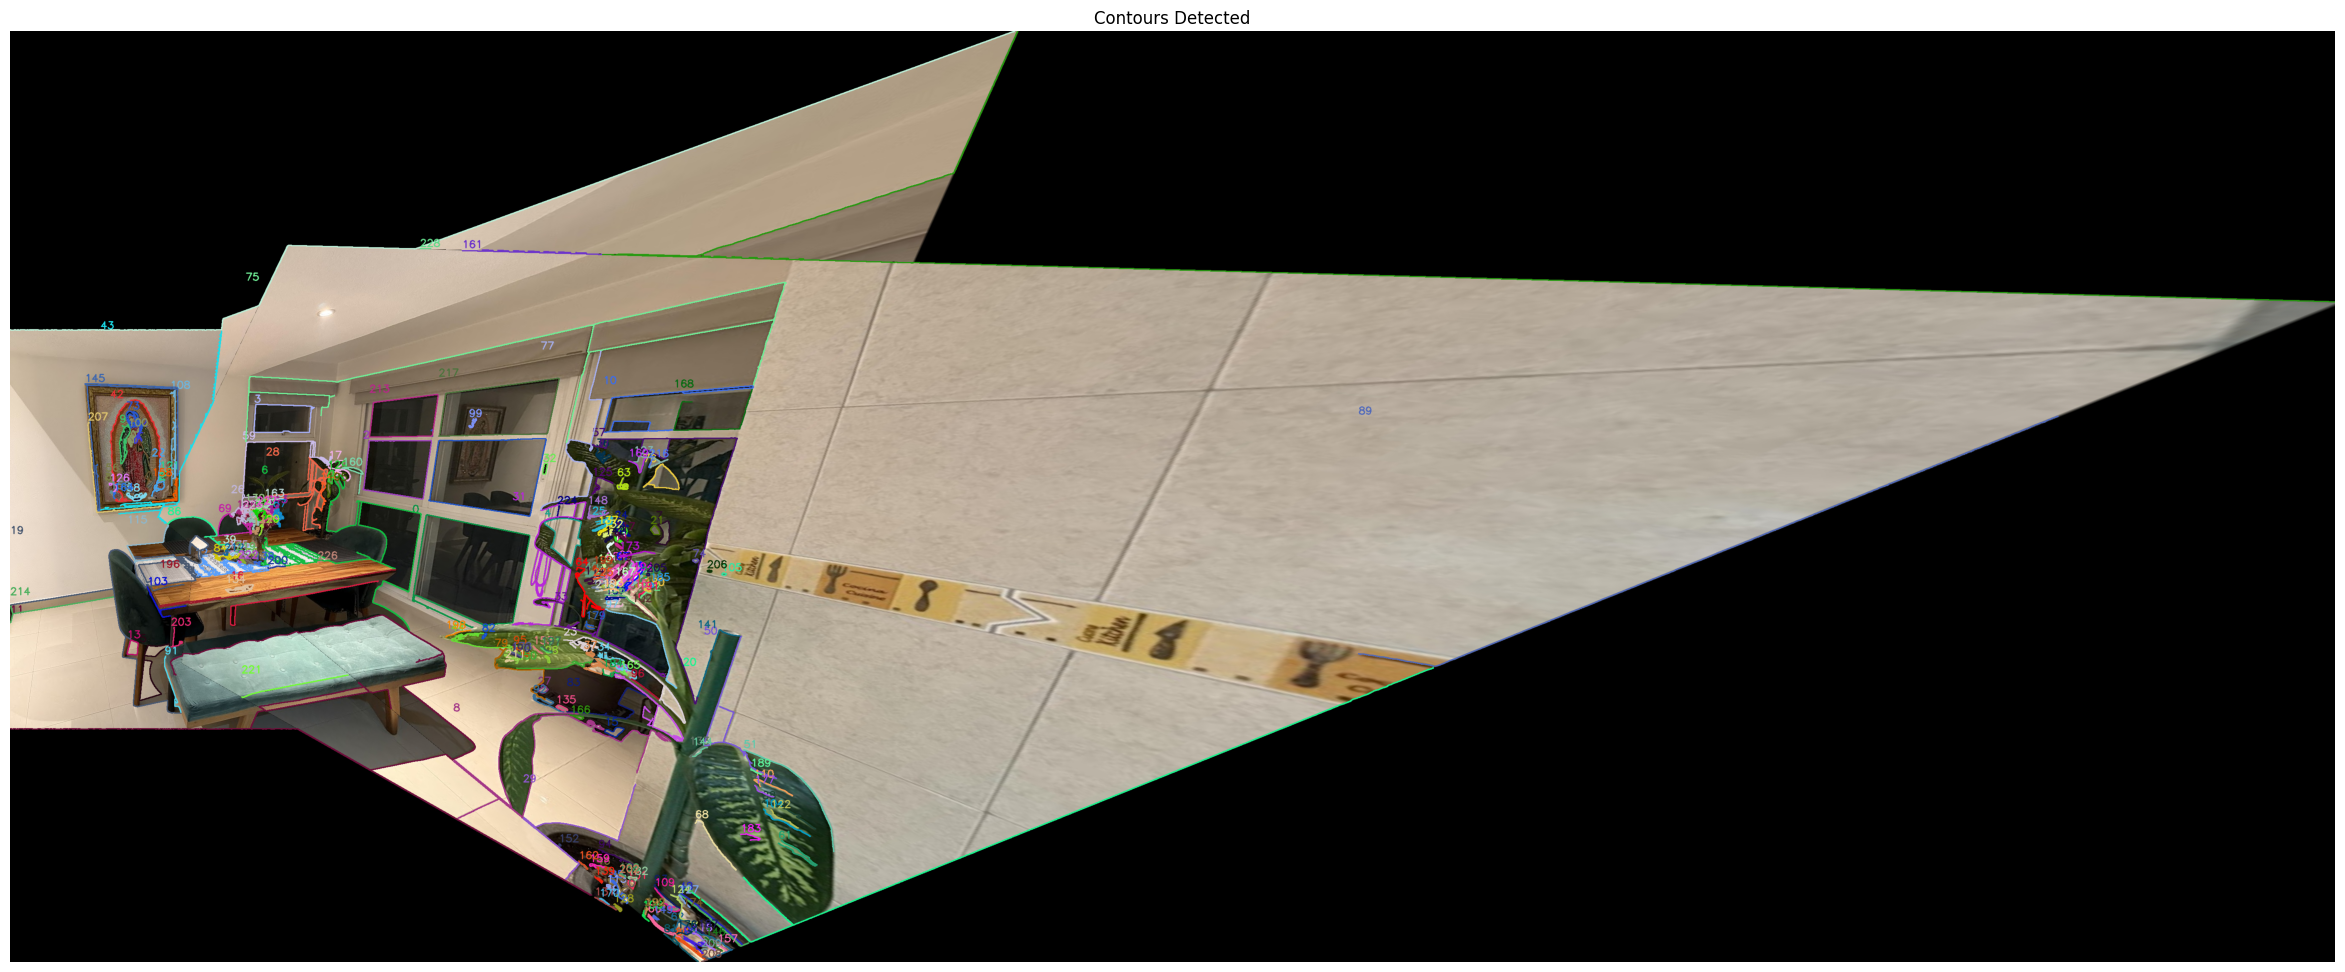

In [ ]:
def get_contour_data(img, show_image=True):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 300)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    contour_img = img.copy()
    contour_data = []

    for i, cnt in enumerate(contours):
        color = tuple(np.random.randint(0, 255, 3).tolist())
        cv2.drawContours(contour_img, [cnt], -1, color, 2)
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.putText(contour_img, str(i), (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

        contour_info = {
            "index": i,
            "contour": cnt,
            "bounding_box": (x, y, w, h),
            "area": cv2.contourArea(cnt)
        }
        contour_data.append(contour_info)

    if show_image:
        plt.figure(figsize=(30, 24))
        plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
        plt.title("Contours Detected")
        plt.axis('off')
        plt.show()

    return contour_data

contours_img1 = get_contour_data(img1)
contours_img2 = get_contour_data(img2)

# Tomamos las medidas del contorno que elegimos

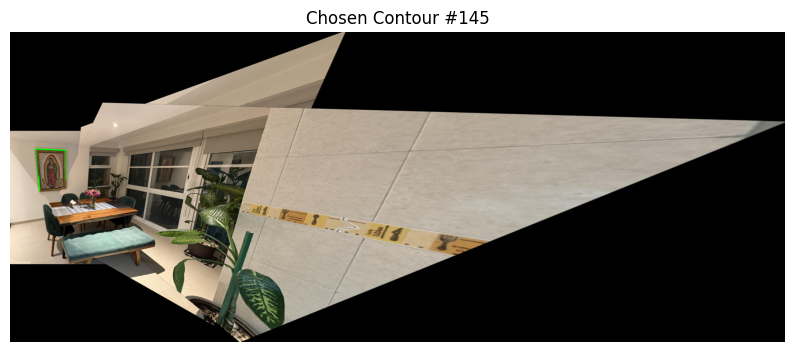

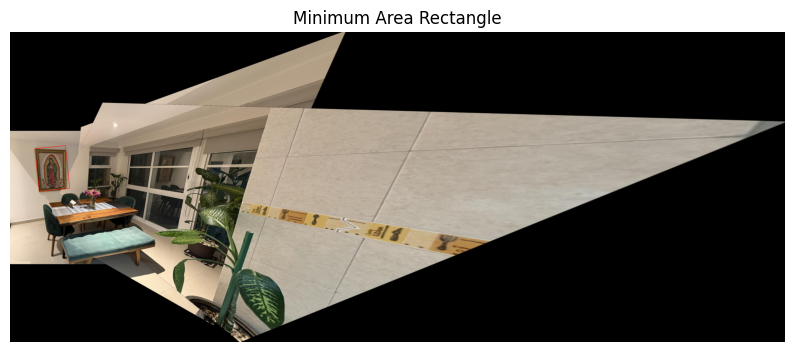

In [ ]:
def draw_chosen_contour(img, contour_data, chosen_index):

    chosen_contour = contour_data[chosen_index]["contour"]

    # Draw only the chosen contour
    output = img.copy()
    cv2.drawContours(output, [chosen_contour], -1, (0, 255, 0), 3)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title(f"Chosen Contour #{chosen_index}")
    plt.axis('off')
    plt.show()

    # Draw minimum area rectangle
    rect = cv2.minAreaRect(chosen_contour)
    box = cv2.boxPoints(rect)
    box = np.int32(box)

    img_m = img.copy()
    cv2.drawContours(img_m, [box], 0, (0, 0, 255), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_m, cv2.COLOR_BGR2RGB))
    plt.title("Minimum Area Rectangle")
    plt.axis('off')
    plt.show()

    # Return rectangle dimensions
    (w, h) = rect[1]
    #print(f"Alto: {w['length']:.2f} px")
    #print(f"Largo: {h['height']:.2f} px")

    return w, h


rect_dims2_l, rect_dims2_h = draw_chosen_contour(img2, contours_img2, chosen_index=145)



# Transformamos pixeles a centimetros

Largo detectado: 217.70 px = 117.0 cm
Escala: 1.8607 px por cm  |  0.5374 cm por px
Prueba: 117.00 cm


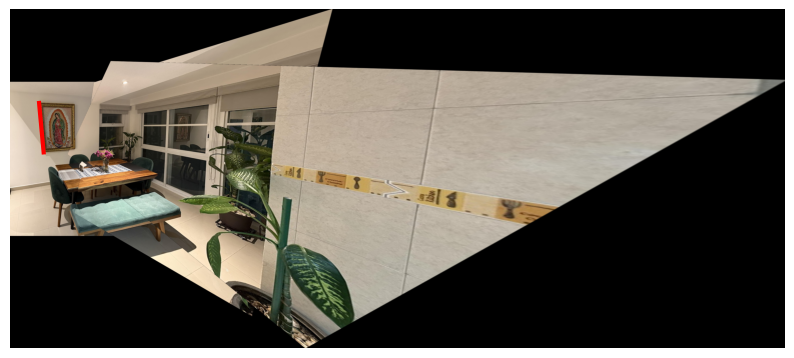

Pixel distance between points: 304.29
Largo detectado: 304.29 px = 117.0 cm
Escala: 2.6008 px por cm  |  0.3845 cm por px
Prueba: 117.00 cm


In [ ]:
# Variables

# Valor conocido
real_height_cm = 117.0

def calculate_scale_from_contour(rect_dims):

    # Valor conocido
    real_height_cm = 117.0

    rect_Height, rect_Lenght = rect_dims

    px_per_cm = rect_Height / real_height_cm
    cm_per_px = real_height_cm / rect_Height
    height_cm = rect_Height * cm_per_px

    print(f"Largo detectado: {rect_Height:.2f} px = {real_height_cm} cm")
    print(f"Escala: {px_per_cm:.4f} px por cm  |  {cm_per_px:.4f} cm por px")
    print(f"Prueba: {height_cm:.2f} cm")

    return px_per_cm, cm_per_px


#Aqui utilizamos el contorno para la distancia

px_per_cm2, cm_per_px2 = calculate_scale_from_contour((rect_dims2_h, rect_dims2_l))

# Midiendolos al utilizar jImage para extraer los puntos manualmente

img1_coordX1, img1_coordY1 = (178, 574)
img1_coordX2, img1_coordY2 = (206, 877)

p1 = (img1_coordX1, img1_coordY1)
p2 = (img1_coordX2, img1_coordY2)

# Mostramos la imagen
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))

# Dibujamos la linea sobre la imagen
x = [img1_coordX1, img1_coordX2]
y = [img1_coordY1, img1_coordY2]
plt.plot(x, y, color='red', linewidth=3)
plt.axis('off')
plt.show()
line_color = (0, 0, 255)
thickness = 1

# Distancia
distance = np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
print(f"Pixel distance between points: {distance:.2f}")

px_per_cm1, cm_per_px1 = calculate_scale_from_contour((distance, 0))

# Midiendo otros objetos

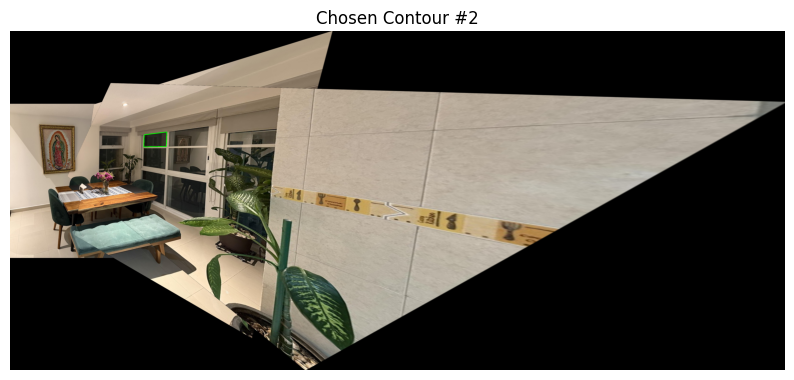

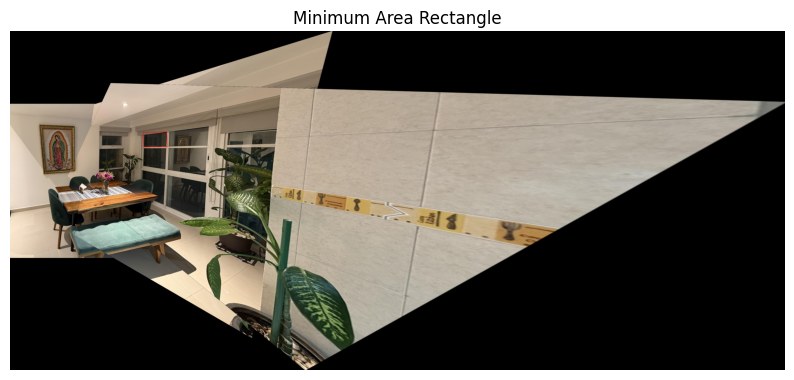

Largo: 34.30548897239918 cm
Alto: 55.539771742046455 cm


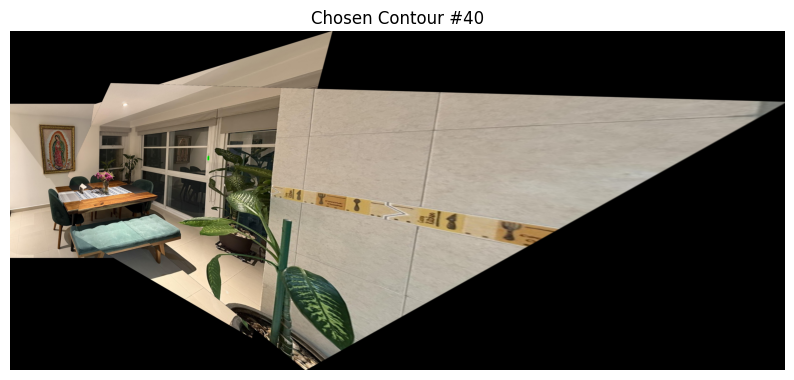

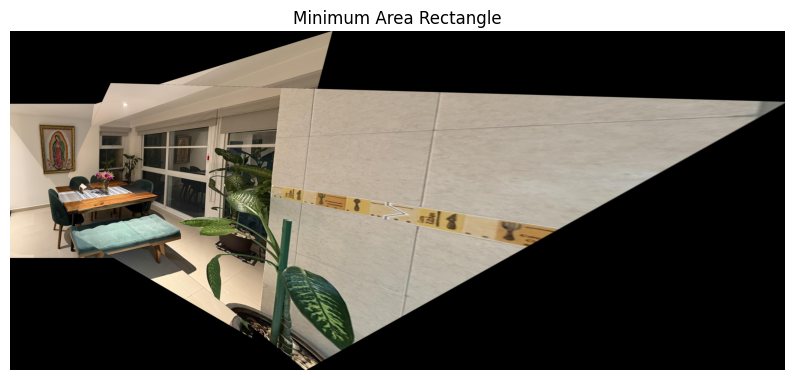

Largo: 3.0460283765919978 cm
Alto: 9.281993176115366 cm


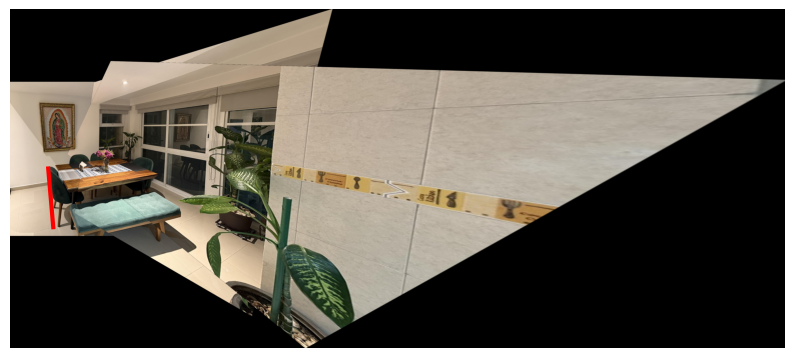

Distancia de la silla en pixeles: 361.33
Alto de la silla: 138.93239357139166 cm


In [ ]:
# Deteccion para la imagen 1 con bordes

dataL, dataH = draw_chosen_contour(img1, contours_img1, chosen_index=2)

height1 = cm_per_px1 * dataH
lenght1 = cm_per_px1 * dataL

print(f"Largo: {lenght1} cm")
print(f"Alto: {height1} cm")

dataL, dataH = draw_chosen_contour(img1, contours_img1, chosen_index=40)

height1 = cm_per_px1 * dataH
lenght1 = cm_per_px1 * dataL

print(f"Largo: {lenght1} cm")
print(f"Alto: {height1} cm")

# Midamos la silla de la misma forma que medimos el cuadro

img1_coordX1, img1_coordY1 = (234, 976)
img1_coordX2, img1_coordY2 = (265, 1336)

p1 = (img1_coordX1, img1_coordY1)
p2 = (img1_coordX2, img1_coordY2)

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))

# Dibujamos la linea sobre la imagen
x = [img1_coordX1, img1_coordX2]
y = [img1_coordY1, img1_coordY2]
plt.plot(x, y, color='red', linewidth=3)
plt.axis('off')
plt.show()
line_color = (0, 0, 255)
thickness = 1

# Distancia
dataChair = np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
print(f"Distancia de la silla en pixeles: {dataChair:.2f}")

heightChair = cm_per_px1 * dataChair
print(f"Alto de la silla: {heightChair} cm")

# Seleccion personalizada de Lineas para la imagen 2

Ingresa las coordenadas de x y y como enteros, e.g., 50 120

Distancia de los pixeles (250, 1240) y (275, 1750) = 510.61 pixeles


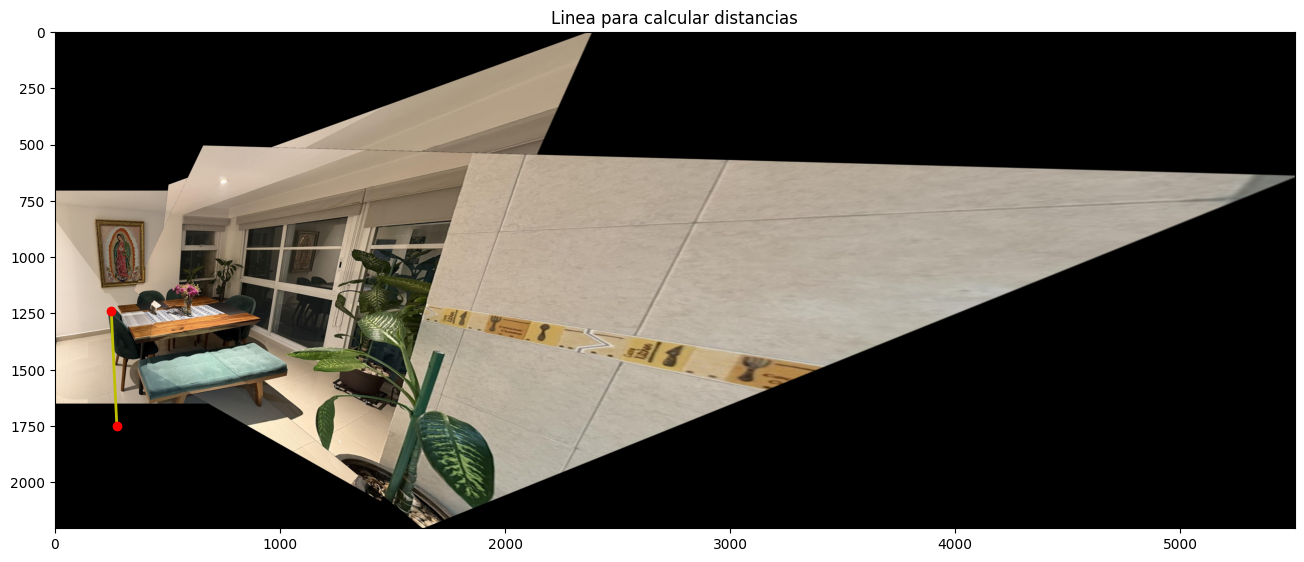

Largo de linea: 274.4167130753078 cm


In [ ]:
def calculate_px_to_cm(lenght):
    lenght_cm = lenght * cm_per_px2
    print(f"Largo de linea: {lenght_cm} cm")

img_m = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(16, 12))
ax.imshow(img_m)
ax.set_title("Linea para calcular distancias")

# Ask user for two coordinate pairs
print("Ingresa las coordenadas de x y y como enteros, e.g., 50 120")

x1, y1 = map(int, input("Ingresa x1 y1: ").split())
x2, y2 = map(int, input("Ingresa x2 y2: ").split())

# Draw points and line on the image
ax.plot([x1, x2], [y1, y2], 'y-', linewidth=2)
ax.plot([x1, x2], [y1, y2], 'ro')
fig.canvas.draw()

# Calculamos la distancia de los pixeles
length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
print(f"\nDistancia de los pixeles ({x1}, {y1}) y ({x2}, {y2}) = {length:.2f} pixeles")


plt.show()
calculate_px_to_cm(length)